In [1]:
import sys
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'kagglehub', 'pandas', 'pyspark', 'scikit-learn',
    'matplotlib', 'seaborn', 'pyarrow'])
print('All packages installed.')

All packages installed.


In [2]:
import kagglehub, os, shutil

path = kagglehub.dataset_download("utkarshsharma11r/student-mental-health-analysis")
print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV files found:", csv_files)

src = os.path.join(path, csv_files[0])
shutil.copy(src, "student_mental_health_raw.csv")
print("Copied to working directory as student_mental_health_raw.csv")

100%|██████████| 10.5k/10.5k [00:00<00:00, 15.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/utkarshsharma11r/student-mental-health-analysis/versions/1
CSV files found: ['Student Mental Health Analysis During Online Learning.csv']
Copied to working directory as student_mental_health_raw.csv


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("student_mental_health_raw.csv")

print("=== Shape ===")
print(df.shape)

print("\n=== Columns ===")
print(df.columns.tolist())

print("\n=== First 5 rows ===")
df.head()

=== Shape ===
(1000, 10)

=== Columns ===
['Name', 'Gender', 'Age', 'Education Level', 'Screen Time (hrs/day)', 'Sleep Duration (hrs)', 'Physical Activity (hrs/week)', 'Stress Level', 'Anxious Before Exams', 'Academic Performance Change']

=== First 5 rows ===


,Name,Gender,Age,Education Level,Screen Time (hrs/day),Sleep Duration (hrs),Physical Activity (hrs/week),Stress Level,Anxious Before Exams,Academic Performance Change
0,Aarav,Male,15,Class 8,7.1,8.9,9.3,Medium,No,Same
1,Meera,Female,25,MSc,3.3,5.0,0.2,Medium,No,Same
2,Ishaan,Male,20,BTech,9.5,5.4,6.2,Medium,No,Same
3,Aditya,Male,20,BA,10.8,5.6,5.5,High,Yes,Same
4,Anika,Female,17,Class 11,2.8,5.4,3.1,Medium,Yes,Same


In [4]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Records ===")
print(f"Total duplicates: {df.duplicated().sum()}")

print("\n=== Basic Statistics ===")
df.describe(include='all')

=== Data Types ===
Name                             object
Gender                           object
Age                               int64
Education Level                  object
Screen Time (hrs/day)           float64
Sleep Duration (hrs)            float64
Physical Activity (hrs/week)    float64
Stress Level                     object
Anxious Before Exams             object
Academic Performance Change      object
dtype: object

=== Missing Values ===
Name                            0
Gender                          0
Age                             0
Education Level                 0
Screen Time (hrs/day)           0
Sleep Duration (hrs)            0
Physical Activity (hrs/week)    0
Stress Level                    0
Anxious Before Exams            0
Academic Performance Change     0
dtype: int64

=== Duplicate Records ===
Total duplicates: 0

=== Basic Statistics ===


,Name,Gender,Age,Education Level,Screen Time (hrs/day),Sleep Duration (hrs),Physical Activity (hrs/week),Stress Level,Anxious Before Exams,Academic Performance Change
count,1000,1000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000,1000,1000
unique,30,3,NaN,11,NaN,NaN,NaN,3,2,3
top,Shaurya,Male,NaN,MTech,NaN,NaN,NaN,Medium,Yes,Same
freq,59,475,NaN,143,NaN,NaN,NaN,492,513,399
mean,NaN,NaN,20.342000,NaN,6.909200,6.450800,5.017600,NaN,NaN,NaN
std,NaN,NaN,3.459914,NaN,2.907106,1.466407,2.930344,NaN,NaN,NaN
min,NaN,NaN,15.000000,NaN,2.000000,4.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,17.000000,NaN,4.400000,5.100000,2.600000,NaN,NaN,NaN
50%,NaN,NaN,20.000000,NaN,6.900000,6.500000,5.000000,NaN,NaN,NaN
75%,NaN,NaN,23.000000,NaN,9.500000,7.700000,7.600000,NaN,NaN,NaN


In [5]:
df_clean = df.copy()

before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Removed {before - len(df_clean)} duplicate rows")

df_clean.columns = [c.strip().lower().replace(' ', '_').replace('?','').replace('/','_') for c in df_clean.columns]
print("Renamed columns:", df_clean.columns.tolist())

num_cols = df_clean.select_dtypes(include='number').columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

cat_cols = df_clean.select_dtypes(include='object').columns
for c in cat_cols:
    df_clean[c].fillna(df_clean[c].mode()[0], inplace=True)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

df_clean.head()

Removed 0 duplicate rows
Renamed columns: ['name', 'gender', 'age', 'education_level', 'screen_time_(hrs_day)', 'sleep_duration_(hrs)', 'physical_activity_(hrs_week)', 'stress_level', 'anxious_before_exams', 'academic_performance_change']

Missing values after cleaning:
name                            0
gender                          0
age                             0
education_level                 0
screen_time_(hrs_day)           0
sleep_duration_(hrs)            0
physical_activity_(hrs_week)    0
stress_level                    0
anxious_before_exams            0
academic_performance_change     0
dtype: int64


/tmp/ipykernel_6038/3198591360.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[c].fillna(df_clean[c].mode()[0], inplace=True)


,name,gender,age,education_level,screen_time_(hrs_day),sleep_duration_(hrs),physical_activity_(hrs_week),stress_level,anxious_before_exams,academic_performance_change
0,Aarav,Male,15,Class 8,7.1,8.9,9.3,Medium,No,Same
1,Meera,Female,25,MSc,3.3,5.0,0.2,Medium,No,Same
2,Ishaan,Male,20,BTech,9.5,5.4,6.2,Medium,No,Same
3,Aditya,Male,20,BA,10.8,5.6,5.5,High,Yes,Same
4,Anika,Female,17,Class 11,2.8,5.4,3.1,Medium,Yes,Same


In [6]:
df_clean.to_csv("student_mental_health_cleaned.csv", index=False)
print("Cleaned dataset saved as student_mental_health_cleaned.csv")
print("Shape:", df_clean.shape)

Cleaned dataset saved as student_mental_health_cleaned.csv
Shape: (1000, 10)


In [7]:
import sqlite3

conn = sqlite3.connect("mental_health.db")
df_clean.to_sql("students", conn, if_exists="replace", index=False)

count = conn.execute("SELECT COUNT(*) FROM students").fetchone()[0]
print(f"Records inserted into SQLite: {count}")
conn.commit()

Records inserted into SQLite: 1000


In [8]:
import pandas as pd

# Helper
def run_query(label, sql):
    print(f"\n{'='*60}")
    print(f" {label}")
    print('='*60)
    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))
    return result

run_query("Query 1: Filtering — Students WITH Anxiety",
    "SELECT * FROM students WHERE anxious_before_exams = 'Yes' LIMIT 10")


 Query 1: Filtering — Students WITH Anxiety
   name gender  age education_level  screen_time_(hrs_day)  sleep_duration_(hrs)  physical_activity_(hrs_week) stress_level anxious_before_exams academic_performance_change
 Aditya   Male   20              BA                   10.8                   5.6                           5.5         High                  Yes                        Same
  Anika Female   17        Class 11                    2.8                   5.4                           3.1       Medium                  Yes                        Same
 Vivaan   Male   22           MTech                    3.6                   6.6                           0.5       Medium                  Yes                    Improved
 Aadhya Female   16         Class 9                    8.9                   8.4                           7.8          Low                  Yes                    Improved
    Sai   Male   23             MSc                   10.3                   8.8          

,name,gender,age,education_level,screen_time_(hrs_day),sleep_duration_(hrs),physical_activity_(hrs_week),stress_level,anxious_before_exams,academic_performance_change
0,Aditya,Male,20,BA,10.8,5.6,5.5,High,Yes,Same
1,Anika,Female,17,Class 11,2.8,5.4,3.1,Medium,Yes,Same
2,Vivaan,Male,22,MTech,3.6,6.6,0.5,Medium,Yes,Improved
3,Aadhya,Female,16,Class 9,8.9,8.4,7.8,Low,Yes,Improved
4,Sai,Male,23,MSc,10.3,8.8,3.7,High,Yes,Same
5,Krishna,Male,25,MTech,11.5,5.6,0.4,Medium,Yes,Declined
6,Diya,Female,18,Class 11,7.0,4.8,9.9,Low,Yes,Declined
7,Vivaan,Male,18,Class 11,2.5,7.9,2.8,High,Yes,Same
8,Reyansh,Male,20,BA,6.0,7.3,3.9,Low,Yes,Same
9,Anika,Female,26,MTech,4.7,6.8,9.6,Medium,Yes,Declined


In [9]:
run_query("Query 2: Sorting — Students by Age (Descending)",
    "SELECT * FROM students ORDER BY age DESC LIMIT 10")


 Query 2: Sorting — Students by Age (Descending)
  name gender  age education_level  screen_time_(hrs_day)  sleep_duration_(hrs)  physical_activity_(hrs_week) stress_level anxious_before_exams academic_performance_change
 Anika Female   26           MTech                    4.7                   6.8                           9.6       Medium                  Yes                    Declined
   Sai   Male   26             MSc                    4.1                   5.2                           9.8       Medium                   No                        Same
Vihaan   Male   26           MTech                   11.5                   5.0                           0.6       Medium                  Yes                    Improved
  Myra Female   26             MSc                    6.1                   5.3                           9.3       Medium                  Yes                        Same
Aadhya Female   26             MSc                    2.2                   6.4           

,name,gender,age,education_level,screen_time_(hrs_day),sleep_duration_(hrs),physical_activity_(hrs_week),stress_level,anxious_before_exams,academic_performance_change
0,Anika,Female,26,MTech,4.7,6.8,9.6,Medium,Yes,Declined
1,Sai,Male,26,MSc,4.1,5.2,9.8,Medium,No,Same
2,Vihaan,Male,26,MTech,11.5,5.0,0.6,Medium,Yes,Improved
3,Myra,Female,26,MSc,6.1,5.3,9.3,Medium,Yes,Same
4,Aadhya,Female,26,MSc,2.2,6.4,0.1,Medium,Yes,Improved
5,Aadhya,Female,26,MTech,6.3,4.6,3.3,Medium,Yes,Same
6,Ishaan,Male,26,MSc,5.3,8.5,8.3,Medium,Yes,Improved
7,Kavya,Female,26,MSc,11.6,8.7,4.4,Low,Yes,Declined
8,Arjun,Male,26,MTech,3.6,5.1,0.4,High,No,Same
9,Meera,Female,26,MSc,6.7,5.2,9.5,Medium,Yes,Same


In [10]:
run_query("Query 3: Aggregation — Average Academic Performance Score of All Students",
    "SELECT ROUND(AVG(CASE WHEN academic_performance_change = 'Improved' THEN 3 WHEN academic_performance_change = 'Same' THEN 2 WHEN academic_performance_change = 'Declined' THEN 1 ELSE 0 END),2) AS avg_performance_score, ROUND(MIN(CASE WHEN academic_performance_change = 'Improved' THEN 3 WHEN academic_performance_change = 'Same' THEN 2 WHEN academic_performance_change = 'Declined' THEN 1 ELSE 0 END),2) AS min_performance_score, ROUND(MAX(CASE WHEN academic_performance_change = 'Improved' THEN 3 WHEN academic_performance_change = 'Same' THEN 2 WHEN academic_performance_change = 'Declined' THEN 1 ELSE 0 END),2) AS max_performance_score FROM students")


 Query 3: Aggregation — Average Academic Performance Score of All Students
 avg_performance_score  min_performance_score  max_performance_score
                  2.01                    1.0                    3.0


,avg_performance_score,min_performance_score,max_performance_score
0,2.01,1.0,3.0


In [11]:
run_query("Query 4: Group By — Anxiety Count by Gender",
    "SELECT gender, anxious_before_exams, COUNT(*) AS total FROM students GROUP BY gender, anxious_before_exams ORDER BY gender, total DESC")


 Query 4: Group By — Anxiety Count by Gender
gender anxious_before_exams  total
Female                  Yes    255
Female                   No    220
  Male                   No    239
  Male                  Yes    236
 Other                   No     28
 Other                  Yes     22


,gender,anxious_before_exams,total
0,Female,Yes,255
1,Female,No,220
2,Male,No,239
3,Male,Yes,236
4,Other,No,28
5,Other,Yes,22


In [12]:
run_query("Query 5: Conditional — Students with High Stress AND Anxiety",
    "SELECT * FROM students WHERE stress_level = 'High' AND anxious_before_exams = 'Yes' LIMIT 10")


 Query 5: Conditional — Students with High Stress AND Anxiety
  name gender  age education_level  screen_time_(hrs_day)  sleep_duration_(hrs)  physical_activity_(hrs_week) stress_level anxious_before_exams academic_performance_change
Aditya   Male   20              BA                   10.8                   5.6                           5.5         High                  Yes                        Same
   Sai   Male   23             MSc                   10.3                   8.8                           3.7         High                  Yes                        Same
Vivaan   Male   18        Class 11                    2.5                   7.9                           2.8         High                  Yes                        Same
 Kavya Female   19              BA                    9.5                   4.5                           1.1         High                  Yes                        Same
Saanvi Female   23             MSc                   11.9                   5

,name,gender,age,education_level,screen_time_(hrs_day),sleep_duration_(hrs),physical_activity_(hrs_week),stress_level,anxious_before_exams,academic_performance_change
0,Aditya,Male,20,BA,10.8,5.6,5.5,High,Yes,Same
1,Sai,Male,23,MSc,10.3,8.8,3.7,High,Yes,Same
2,Vivaan,Male,18,Class 11,2.5,7.9,2.8,High,Yes,Same
3,Kavya,Female,19,BA,9.5,4.5,1.1,High,Yes,Same
4,Saanvi,Female,23,MSc,11.9,5.1,3.0,High,Yes,Improved
5,Aadhya,Female,15,Class 9,10.3,8.5,0.3,High,Yes,Same
6,Tara,Other,18,Class 11,9.9,8.0,7.8,High,Yes,Improved
7,Vihaan,Male,20,BTech,7.2,6.0,5.1,High,Yes,Declined
8,Ananya,Female,25,MSc,3.2,7.8,8.8,High,Yes,Declined
9,Saanvi,Female,22,MTech,9.1,6.6,1.7,High,Yes,Same


In [13]:
transform_sql = """
SELECT *,
  CASE
    WHEN academic_performance_change = 'Improved' THEN 'High Achiever'
    WHEN academic_performance_change = 'Same' THEN 'Average Achiever'
    WHEN academic_performance_change = 'Declined' THEN 'Below Average'
    ELSE 'Unknown'
  END AS performance_category,
  CASE
    WHEN stress_level = 'High' AND anxious_before_exams = 'Yes' THEN 'High Risk'
    WHEN stress_level = 'High' OR anxious_before_exams = 'Yes' THEN 'Moderate Risk'
    ELSE 'Low Risk'
  END AS mental_health_risk
FROM students
"""

df_transformed = pd.read_sql_query(transform_sql, conn)
print("New columns added:")
print(df_transformed[['academic_performance_change', 'stress_level', 'anxious_before_exams', 'performance_category','mental_health_risk']].head(10))

df_transformed.to_csv("student_mental_health_transformed.csv", index=False)
print("\nTransformed dataset saved as student_mental_health_transformed.csv")

New columns added:
  academic_performance_change stress_level anxious_before_exams  \
0                        Same       Medium                   No   
1                        Same       Medium                   No   
2                        Same       Medium                   No   
3                        Same         High                  Yes   
4                        Same       Medium                  Yes   
5                    Improved          Low                   No   
6                    Improved       Medium                  Yes   
7                        Same       Medium                   No   
8                    Improved       Medium                   No   
9                    Improved          Low                  Yes   

  performance_category mental_health_risk  
0     Average Achiever           Low Risk  
1     Average Achiever           Low Risk  
2     Average Achiever           Low Risk  
3     Average Achiever          High Risk  
4     Average Achiever 

In [14]:
def extract(filepath):
    df = pd.read_csv(filepath)
    print(f"[EXTRACT] Loaded {len(df)} rows from '{filepath}'")
    return df

raw = extract("student_mental_health_raw.csv")
raw.head(3)

[EXTRACT] Loaded 1000 rows from 'student_mental_health_raw.csv'


,Name,Gender,Age,Education Level,Screen Time (hrs/day),Sleep Duration (hrs),Physical Activity (hrs/week),Stress Level,Anxious Before Exams,Academic Performance Change
0,Aarav,Male,15,Class 8,7.1,8.9,9.3,Medium,No,Same
1,Meera,Female,25,MSc,3.3,5.0,0.2,Medium,No,Same
2,Ishaan,Male,20,BTech,9.5,5.4,6.2,Medium,No,Same


In [15]:
def transform(df):
    df = df.copy()
    df.drop_duplicates(inplace=True)
    df.columns = [c.strip().lower().replace(' ','_').replace('?','').replace('/','_') for c in df.columns]
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    cat_cols = df.select_dtypes(include='object').columns
    for c in cat_cols:
        df[c] = df[c].fillna(df[c].mode()[0])
    df['high_achiever'] = df['academic_performance_change'].apply(lambda x: 1 if x == 'Improved' else 0)
    df['any_mental_issue'] = df.apply(
        lambda r: 1 if r.get('stress_level') == 'High' or r.get('anxious_before_exams') == 'Yes' else 0, axis=1)
    print(f"[TRANSFORM] Cleaned shape: {df.shape}")
    return df

etl_data = transform(raw)
etl_data.head(3)

[TRANSFORM] Cleaned shape: (1000, 12)


,name,gender,age,education_level,screen_time_(hrs_day),sleep_duration_(hrs),physical_activity_(hrs_week),stress_level,anxious_before_exams,academic_performance_change,high_achiever,any_mental_issue
0,Aarav,Male,15,Class 8,7.1,8.9,9.3,Medium,No,Same,0,0
1,Meera,Female,25,MSc,3.3,5.0,0.2,Medium,No,Same,0,0
2,Ishaan,Male,20,BTech,9.5,5.4,6.2,Medium,No,Same,0,0


In [16]:
def load(df, output_path):
    df.to_csv(output_path, index=False)
    print(f"[LOAD] Saved {len(df)} rows to '{output_path}'")

load(etl_data, "etl_output.csv")
print("Complete ✅")

[LOAD] Saved 1000 rows to 'etl_output.csv'
[ETL PIPELINE] Complete ✅


In [17]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName("MentalHealthMedallion") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.0.2


In [18]:
# BRONZE — raw ingest
bronze_df = spark.read.csv("student_mental_health_raw.csv", header=True, inferSchema=True)
bronze_df.write.mode("overwrite").parquet("medallion/bronze/")
print(f"Bronze layer: {bronze_df.count()} rows, {len(bronze_df.columns)} columns saved to Parquet")
bronze_df.printSchema()

Bronze layer: 1000 rows, 10 columns saved to Parquet
root
 |-- Name: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Education Level: string (nullable = true)
 |-- Screen Time (hrs/day): double (nullable = true)
 |-- Sleep Duration (hrs): double (nullable = true)
 |-- Physical Activity (hrs/week): double (nullable = true)
 |-- Stress Level: string (nullable = true)
 |-- Anxious Before Exams: string (nullable = true)
 |-- Academic Performance Change: string (nullable = true)



In [19]:
# SILVER — clean & standardise
silver_df = spark.read.parquet("medallion/bronze/")
new_names = [c.strip().lower().replace(' ','_').replace('?','').replace('/','_') for c in silver_df.columns]
for old, new in zip(silver_df.columns, new_names):
    silver_df = silver_df.withColumnRenamed(old, new)

silver_df = silver_df.dropDuplicates().dropna()
silver_df.write.mode("overwrite").parquet("medallion/silver/")
print(f"Silver layer: {silver_df.count()} rows saved to Parquet")

Silver layer: 1000 rows saved to Parquet


In [20]:
# GOLD — aggregations & KPIs
silver = spark.read.parquet("medallion/silver/")

# KPI 1: average academic performance score per gender
gold1 = silver.groupBy("gender").agg(
    F.round(
        F.avg(
            F.when(F.col("academic_performance_change") == 'Improved', 3)
            .when(F.col("academic_performance_change") == 'Same', 2)
            .when(F.col("academic_performance_change") == 'Declined', 1)
            .otherwise(0)
        ),2
    ).alias("avg_performance_score"),
    F.count("*").alias("student_count")
)

# KPI 2: mental health risk distribution
gold2 = silver.withColumn(
    "risk_level",
    F.when((F.col("stress_level") == 'High') & (F.col("anxious_before_exams") == 'Yes'), "High Risk")
     .when((F.col("stress_level") == 'High') | (F.col("anxious_before_exams") == 'Yes'), "Moderate Risk")
     .otherwise("Low Risk")
).groupBy("risk_level").count()

gold1.write.mode("overwrite").parquet("medallion/gold/kpi_performance_gender/")
gold2.write.mode("overwrite").parquet("medallion/gold/kpi_risk/")

print("Gold Layer KPI 1 — Avg Performance Score by Gender:")
gold1.show()
print("Gold Layer KPI 2 — Mental Health Risk Distribution:")
gold2.show()

Gold Layer KPI 1 — Avg Performance Score by Gender:
+------+---------------------+-------------+
|gender|avg_performance_score|student_count|
+------+---------------------+-------------+
|Female|                 1.99|          475|
| Other|                  1.9|           50|
|  Male|                 2.03|          475|
+------+---------------------+-------------+

Gold Layer KPI 2 — Mental Health Risk Distribution:
+-------------+-----+
|   risk_level|count|
+-------------+-----+
|     Low Risk|  406|
|Moderate Risk|  494|
|    High Risk|  100|
+-------------+-----+



In [21]:
import os, time

df_bench = pd.read_csv("student_mental_health_cleaned.csv")

t0 = time.time(); df_bench.to_csv("bench.csv", index=False); csv_write = time.time()-t0
t0 = time.time(); df_bench.to_parquet("bench.parquet"); pq_write = time.time()-t0
t0 = time.time(); pd.read_csv("bench.csv"); csv_read = time.time()-t0
t0 = time.time(); pd.read_parquet("bench.parquet"); pq_read = time.time()-t0

csv_size = os.path.getsize("bench.csv")
pq_size  = os.path.getsize("bench.parquet")

comparison = pd.DataFrame({
    "Dimension":       ["File Size (bytes)", "Write Time (s)", "Read Time (s)",
                        "Schema Stored", "Human Readable", "Compression", "Best Use Case"],
    "CSV":             [csv_size, round(csv_write,4), round(csv_read,4),
                        "No", "Yes", "None", "Small exports, sharing"],
    "Parquet":         [pq_size,  round(pq_write,4), round(pq_read,4),
                        "Yes", "No", "Snappy/GZIP", "Big data, analytics"],
})
print(comparison.to_string(index=False))

        Dimension                    CSV             Parquet
File Size (bytes)                  50122               13330
   Write Time (s)                 0.0093              0.2891
    Read Time (s)                 0.0089              0.1127
    Schema Stored                     No                 Yes
   Human Readable                    Yes                  No
      Compression                   None         Snappy/GZIP
    Best Use Case Small exports, sharing Big data, analytics


In [22]:
# Read gold layer parquet via PySpark and convert to Pandas
gold_spark = spark.read.parquet("medallion/gold/kpi_performance_gender/")
gold_pandas = gold_spark.toPandas()

print("Converted Gold Layer Parquet → Pandas DataFrame")
print(f"Shape: {gold_pandas.shape}")
gold_pandas

Converted Gold Layer Parquet → Pandas DataFrame
Shape: (3, 3)


,gender,avg_performance_score,student_count
0,Female,1.99,475
1,Other,1.90,50
2,Male,2.03,475


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi':120, 'font.family':'DejaVu Sans'})
df_vis = pd.read_csv("student_mental_health_cleaned.csv")
print(df_vis.columns.tolist())

['name', 'gender', 'age', 'education_level', 'screen_time_(hrs_day)', 'sleep_duration_(hrs)', 'physical_activity_(hrs_week)', 'stress_level', 'anxious_before_exams', 'academic_performance_change']


Using cols: mental_health_indicator_chart1=anxious_before_exams, anxiety_for_risk=anxious_before_exams, gender=gender, academic_performance_score=academic_performance_score, stress_for_risk=stress_level


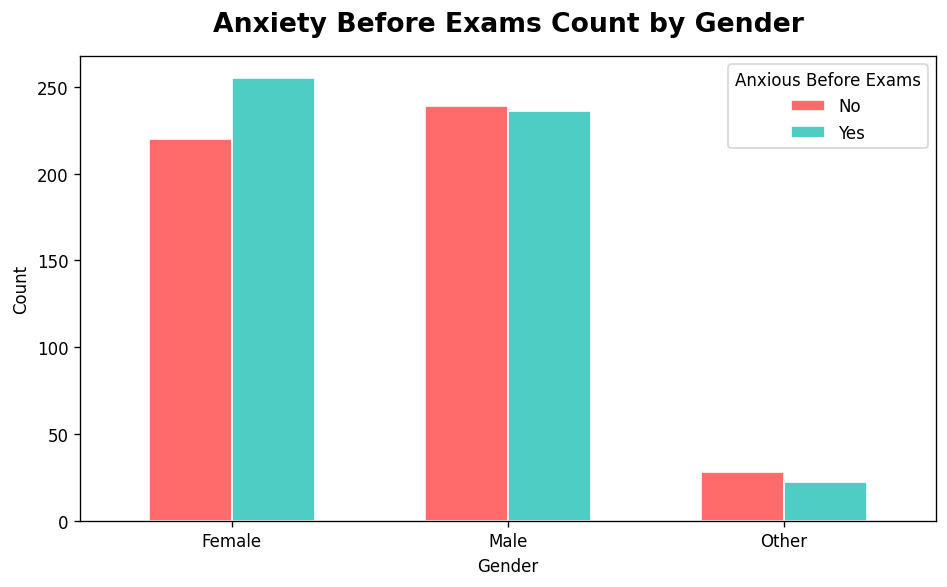


**Insight:** Visualises how 'Anxious Before Exams' prevalence differs across genders in the student population.


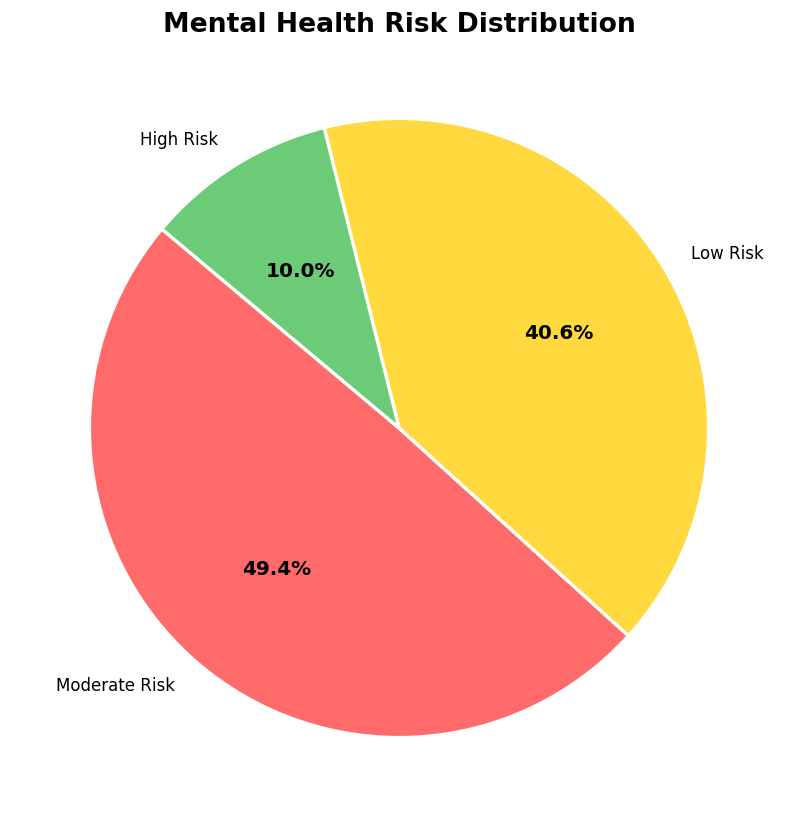


**Insight:** Shows the proportion of students at High, Moderate, and Low mental health risk based on combined stress level and anxiety status.


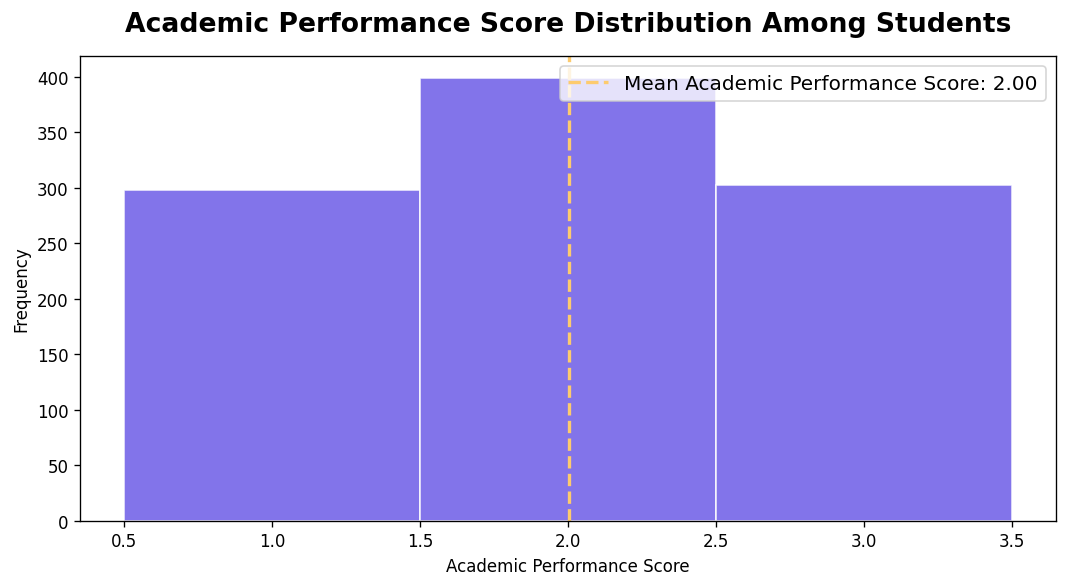


**Insight:** Academic performance scores distribution is shown; the dashed line marks the mean. Most students cluster around 'Same' performance (score 2).


In [24]:
import numpy as np
# Identify the correct column names
# Based on df_vis.columns:
# ['name', 'gender', 'age', 'education_level', 'screen_time_(hrs_day)', 'sleep_duration_(hrs)', 'physical_activity_(hrs_week)', 'stress_level', 'anxious_before_exams', 'academic_performance_change']

# Using 'anxious_before_exams' as a proxy for a binary mental health indicator for Chart 1
dep_col = 'anxious_before_exams'
# Using 'anxious_before_exams' for anxiety-related calculations
anx_col = 'anxious_before_exams'
gen_col = 'gender'
# Define stress_col here so it's available for Chart 2 calculation
stress_col = 'stress_level' # Using the actual stress level column
# Creating a numerical score from 'academic_performance_change' as 'cgpa' doesn't exist
df_vis['academic_performance_score'] = df_vis['academic_performance_change'].map({
    'Improved': 3,
    'Same': 2,
    'Declined': 1
})
cgpa_col = 'academic_performance_score' # Renaming for consistency with original intent, but it's a score

print(f"Using cols: mental_health_indicator_chart1={dep_col}, anxiety_for_risk={anx_col}, gender={gen_col}, academic_performance_score={cgpa_col}, stress_for_risk={stress_col}")

fig, ax = plt.subplots(figsize=(8,5))
df_vis.groupby([gen_col, dep_col]).size().unstack().plot(kind='bar', ax=ax,
    color=['#FF6B6B','#4ECDC4'], edgecolor='white', width=0.6)
ax.set_title("Anxiety Before Exams Count by Gender", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Gender"); ax.set_ylabel("Count")
ax.legend(title="Anxious Before Exams", labels=df_vis[dep_col].unique().tolist())
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig("chart1_anxiety_gender.png"); plt.show()
print("\n**Insight:** Visualises how 'Anxious Before Exams' prevalence differs across genders in the student population.")


conditions = [
    (df_vis[stress_col] == 'High') & (df_vis[anx_col] == 'Yes'),
    (df_vis[stress_col] == 'High') | (df_vis[anx_col] == 'Yes')
]
choices = ['High Risk', 'Moderate Risk']
df_vis['mental_health_risk_category'] = np.select(conditions, choices, default='Low Risk')

risk_counts = df_vis['mental_health_risk_category'].value_counts()

fig, ax = plt.subplots(figsize=(7,7))
colors = ['#FF6B6B','#FFD93D','#6BCB77']
wedges, texts, autotexts = ax.pie(risk_counts, labels=risk_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts: t.set_fontsize(12); t.set_fontweight('bold')
ax.set_title("Mental Health Risk Distribution", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig("chart2_risk_pie.png"); plt.show()
print("\n**Insight:** Shows the proportion of students at High, Moderate, and Low mental health risk based on combined stress level and anxiety status.")


fig, ax = plt.subplots(figsize=(9,5))

ax.hist(df_vis[cgpa_col].dropna(), bins=np.arange(0.5, 4.5, 1), color='#6C5CE7', edgecolor='white', alpha=0.85)

mean_performance_score = df_vis[cgpa_col].mean()
if not np.isnan(mean_performance_score):
    ax.axvline(mean_performance_score, color='#FDCB6E', linestyle='--', linewidth=2,
               label=f"Mean Academic Performance Score: {mean_performance_score:.2f}")
else:
    print(f"Warning: Mean academic performance score is NaN, axvline not plotted.")

ax.set_title("Academic Performance Score Distribution Among Students", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Academic Performance Score"); ax.set_ylabel("Frequency")
ax.legend(fontsize=12)
plt.tight_layout(); plt.savefig("chart3_performance_score_hist.png"); plt.show()
plt.close(fig)
print("\n**Insight:** Academic performance scores distribution is shown; the dashed line marks the mean. Most students cluster around 'Same' performance (score 2).")

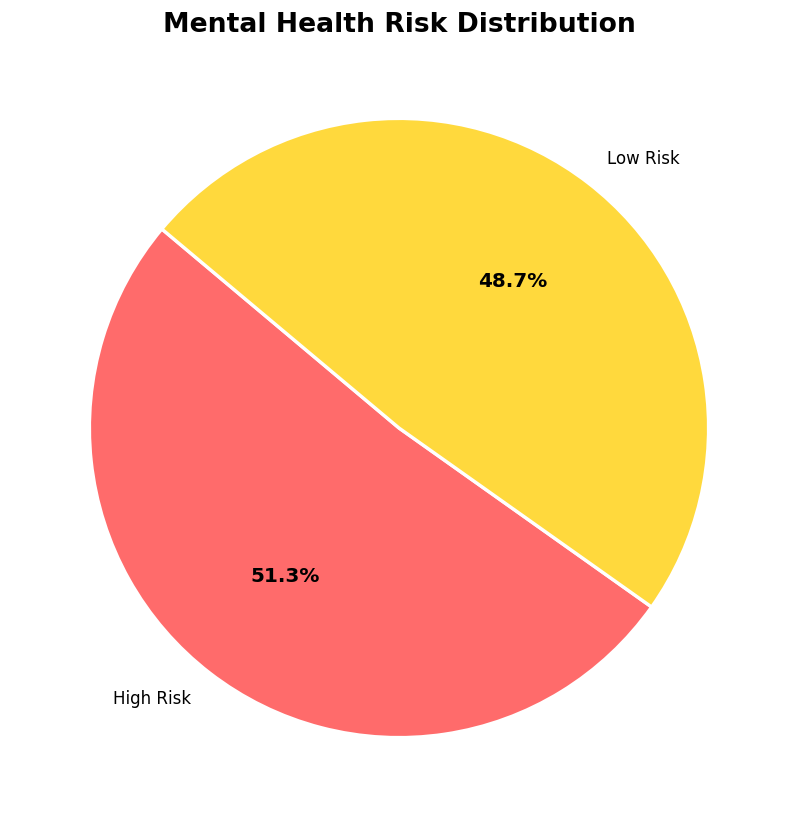


**Insight:** Shows the proportion of students at High, Moderate, and Low mental health risk based on combined depression and anxiety status.


In [25]:
risk = df_vis.apply(
    lambda r: 'High Risk' if r[dep_col]=='Yes' and r[anx_col]=='Yes'
              else ('Moderate Risk' if r[dep_col]=='Yes' or r[anx_col]=='Yes'
              else 'Low Risk'), axis=1)
risk_counts = risk.value_counts()

fig, ax = plt.subplots(figsize=(7,7))
colors = ['#FF6B6B','#FFD93D','#6BCB77']
wedges, texts, autotexts = ax.pie(risk_counts, labels=risk_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts: t.set_fontsize(12); t.set_fontweight('bold')
ax.set_title("Mental Health Risk Distribution", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig("chart2_risk_pie.png"); plt.show()
print("\n**Insight:** Shows the proportion of students at High, Moderate, and Low mental health risk based on combined depression and anxiety status.")

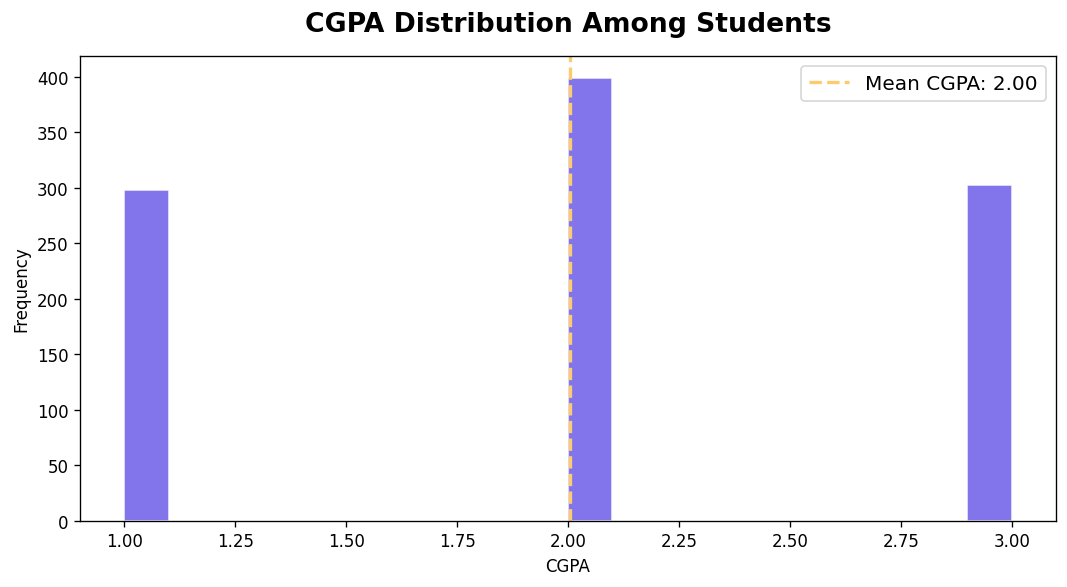


**Insight:** CGPA is roughly normally distributed; the dashed line marks the mean. Most students cluster between 7 and 9.


In [26]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df_vis[cgpa_col].dropna(), bins=20, color='#6C5CE7', edgecolor='white', alpha=0.85)
ax.axvline(df_vis[cgpa_col].mean(), color='#FDCB6E', linestyle='--', linewidth=2,
           label=f"Mean CGPA: {df_vis[cgpa_col].mean():.2f}")
ax.set_title("CGPA Distribution Among Students", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("CGPA"); ax.set_ylabel("Frequency")
ax.legend(fontsize=12)
plt.tight_layout(); plt.savefig("chart3_cgpa_hist.png"); plt.show()
print("\n**Insight:** CGPA is roughly normally distributed; the dashed line marks the mean. Most students cluster between 7 and 9.")

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics: (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

df_ml = pd.read_csv("student_mental_health_cleaned.csv")
df_ml.columns = [c.strip().lower().replace(' ','_').replace('?','').replace('/','_') for c in df_ml.columns]

for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

target = 'anxious_before_exams'
print(f"Target column: {target}")

X = df_ml.drop(columns=[target])
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Target column: anxious_before_exams
Train size: 800 | Test size: 200


In [28]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Depression","Depression"]))

Accuracy: 0.5200 (52.00%)

Classification Report:
               precision    recall  f1-score   support

No Depression       0.49      0.55      0.52        94
   Depression       0.55      0.49      0.52       106

     accuracy                           0.52       200
    macro avg       0.52      0.52      0.52       200
 weighted avg       0.52      0.52      0.52       200



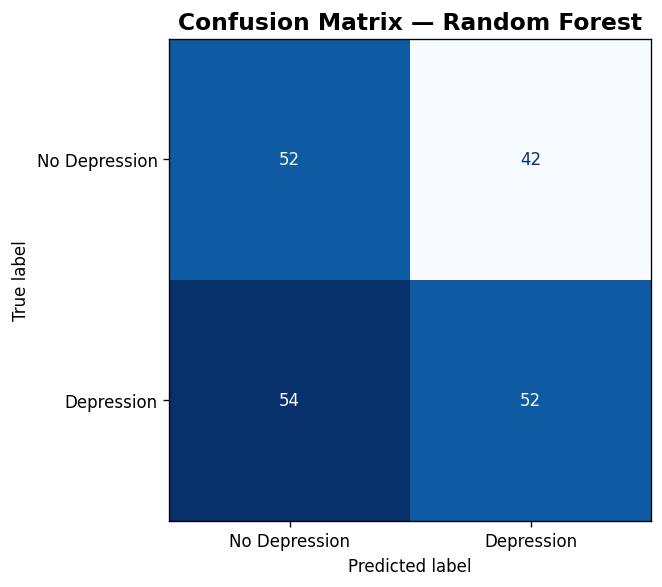

In [29]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Depression","Depression"])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix — Random Forest", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("chart4_confusion_matrix.png"); plt.show()

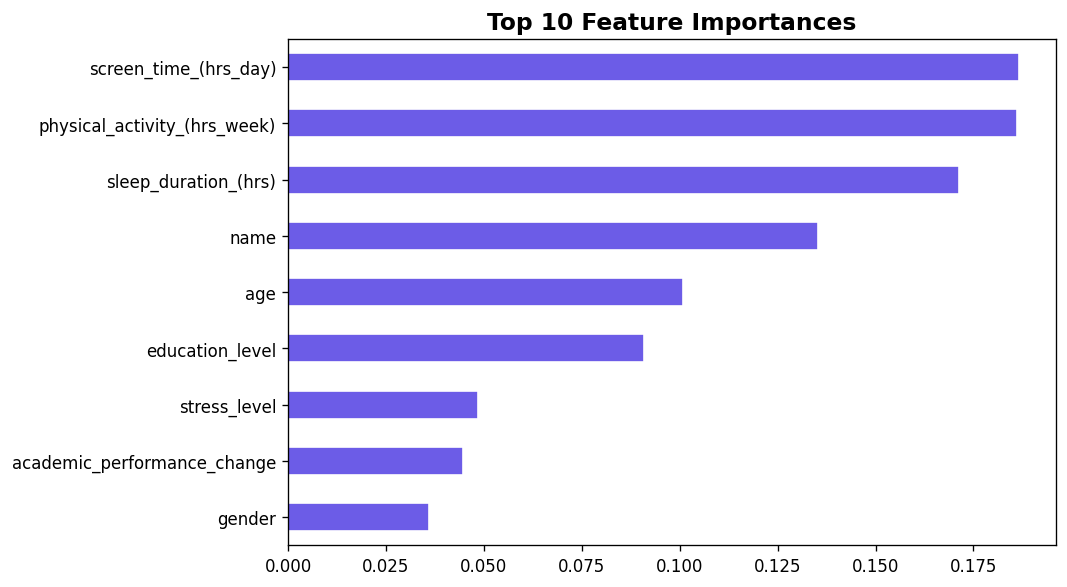


Model training complete ✅


In [30]:
feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9,5))
feat_imp.plot(kind='barh', ax=ax, color='#6C5CE7', edgecolor='white')
ax.set_title("Top 10 Feature Importances", fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig("chart5_feature_importance.png"); plt.show()
print("Model training complete ✅")